# 03 — Baseline U-Net Training

**Project:** BraTS-PEDs glioma segmentation  
**Model:** 2D U-Net · ResNet34 encoder · ImageNet pretrained  
**Loss:** Combined Dice + Focal  
**Optimiser:** AdamW + CosineAnnealingLR  

### Two-phase training strategy
| Phase | Encoder | Epochs | Rationale |
|---|---|---|---|
| 1 — Warm-up | **Frozen** | 5 | Prevents destroying ImageNet weights while decoder is random |
| 2 — Fine-tune | **Unfrozen** | remaining | Full end-to-end optimisation |

### Input contract
- Pre-extracted `.npy` slices in `processed_dataset/`
- Image shape: `[4, 240, 240]` · float32 · Z-score normalised
- Mask shape:  `[240, 240]` · int8  · labels {0,1,2,3}
- Center-cropped to **192×192** before forwarding

---

## 1 — Imports & reproducibility

In [1]:
import os
import sys
import json
import random
import warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from torch.utils.data import DataLoader

# Add project root to path so `src` is importable
PROJECT_ROOT = Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset import BraTSDataset
from src.losses import CombinedLoss
from src.train_utils import (
    get_augmentation,
    get_class_weights,
    train_one_epoch,
    evaluate,
    set_encoder_trainable,
    save_checkpoint,
    load_checkpoint,
    format_metrics,
)

warnings.filterwarnings("ignore", category=UserWarning)

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print(f"PyTorch  : {torch.__version__}")
print(f"SMP      : {smp.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")

PyTorch  : 2.11.0+cu128
SMP      : 0.5.0
CUDA     : True


## 2 — Configuration

In [2]:
# ── Paths ───────────────────────────────────────────────────────────────────
DATA_DIR   = PROJECT_ROOT / "processed_dataset"
CKPT_DIR   = PROJECT_ROOT / "checkpoints" / "unet"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

BEST_CKPT  = str(CKPT_DIR / "best.pth")
LAST_CKPT  = str(CKPT_DIR / "last.pth")

# ── Model ───────────────────────────────────────────────────────────────────
ENCODER      = "resnet34"
ENCODER_WEIGHTS = "imagenet"
NUM_CLASSES  = 4          # 0=BG, 1=NCR, 2=ED, 3=ET
IN_CHANNELS  = 4          # t1c, t1n, t2f, t2w
CROP_SIZE    = 192

# ── Training ────────────────────────────────────────────────────────────────
BATCH_SIZE        = 16
NUM_WORKERS       = 4
PIN_MEMORY        = True

PHASE1_EPOCHS     = 5     # encoder frozen
PHASE2_EPOCHS     = 25    # full fine-tuning
TOTAL_EPOCHS      = PHASE1_EPOCHS + PHASE2_EPOCHS

LR_PHASE1         = 3e-4  # higher LR: only decoder is trained
LR_PHASE2         = 1e-4  # lower LR: full model, prevent catastrophic forgetting
WEIGHT_DECAY      = 1e-4

# ── Loss ────────────────────────────────────────────────────────────────────
DICE_WEIGHT       = 1.0
FOCAL_WEIGHT      = 1.0
FOCAL_GAMMA       = 2.0
IGNORE_BACKGROUND = True  # exclude class-0 from Dice average

# ── Device ──────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── AMP (mixed precision) ───────────────────────────────────────────────────
USE_AMP = DEVICE.type == "cuda"

print(f"Device   : {DEVICE}")
print(f"AMP      : {USE_AMP}")
print(f"Crop     : {CROP_SIZE}×{CROP_SIZE}")
print(f"Epochs   : {PHASE1_EPOCHS} (frozen) + {PHASE2_EPOCHS} (fine-tune) = {TOTAL_EPOCHS}")
print(f"Checkpoints → {CKPT_DIR}")

Device   : cuda
AMP      : True
Crop     : 192×192
Epochs   : 5 (frozen) + 25 (fine-tune) = 30
Checkpoints → C:\Users\lrnzp\OneDrive\Desktop\POLITO\MAGISTRALE\Secondo Anno\Primo Semestre\AI in Medicine\Project\checkpoints\unet


## ✅ Pre-flight Sanity Check

Run this cell immediately after configuration.  
Three independent tests — each prints **PASS** or **FAIL**.  
All three must pass before starting the training loop.


In [3]:

# =============================================================================
# PRE-FLIGHT SANITY CHECK
# Self-contained: creates its own mini model/loader/loss — no dependency on
# subsequent cells.  Run before the training loop to confirm the full
# pipeline is wired correctly and CUDA is active.
# =============================================================================

import traceback
import torch
import segmentation_models_pytorch as smp
from torch.utils.data import DataLoader
from src.dataset import BraTSDataset
from src.losses import CombinedLoss
from src.train_utils import get_augmentation, get_class_weights, center_crop

_PASS = "  ✅  PASS"
_FAIL = "  ❌  FAIL"
_all_passed = True

# Force GPU — override DEVICE in case config cell ran before CUDA was available
DEVICE = torch.device("cuda")
USE_AMP = True

# ─────────────────────────────────────────────────────────────────────────────
# TEST 1 — Hardware Check
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("TEST 1 — Hardware / CUDA")
print("=" * 60)
try:
    assert torch.cuda.is_available(), "torch.cuda.is_available() returned False"

    gpu_name  = torch.cuda.get_device_name(0)
    vram_total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    vram_alloc = torch.cuda.memory_allocated(0) / 1024**3

    print(f"  GPU name       : {gpu_name}")
    print(f"  VRAM total     : {vram_total:.2f} GB")
    print(f"  VRAM allocated : {vram_alloc:.3f} GB")
    print(_PASS)
except Exception as e:
    print(f"  Error: {e}")
    print(_FAIL)
    _all_passed = False

# ─────────────────────────────────────────────────────────────────────────────
# TEST 2 — DataLoader Check
# ─────────────────────────────────────────────────────────────────────────────
print()
print("=" * 60)
print("TEST 2 — DataLoader (one batch from training split)")
print("=" * 60)
_batch_images = None
_batch_masks  = None
try:
    _check_ds = BraTSDataset(str(DATA_DIR / "train"), augment=get_augmentation(p=0.5))
    _check_loader = DataLoader(_check_ds, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=0)   # num_workers=0 for quick check
    _batch_images, _batch_masks = next(iter(_check_loader))

    print(f"  images — shape : {tuple(_batch_images.shape)}  dtype : {_batch_images.dtype}")
    print(f"  masks  — shape : {tuple(_batch_masks.shape)}   dtype : {_batch_masks.dtype}")
    print(f"  images — range : [{_batch_images.min():.3f}, {_batch_images.max():.3f}]")
    print(f"  masks  — unique labels : {_batch_masks.unique().tolist()}")

    assert _batch_images.shape == (BATCH_SIZE, IN_CHANNELS, 240, 240), \
        f"Unexpected image shape: {_batch_images.shape}"
    assert _batch_masks.shape  == (BATCH_SIZE, 240, 240), \
        f"Unexpected mask shape: {_batch_masks.shape}"
    assert _batch_images.dtype == torch.float32, "Images should be float32"
    assert _batch_masks.dtype  == torch.int64,   "Masks should be int64"

    print(_PASS)
except Exception as e:
    traceback.print_exc()
    print(_FAIL)
    _all_passed = False

# ─────────────────────────────────────────────────────────────────────────────
# TEST 3 — Single-Step Training Check
# ─────────────────────────────────────────────────────────────────────────────
print()
print("=" * 60)
print("TEST 3 — Forward pass + loss + backward + optimizer step")
print("=" * 60)
try:
    assert _batch_images is not None, "TEST 2 must pass before TEST 3"

    # Mini model (same architecture, same device)
    _check_model = smp.Unet(
        encoder_name=ENCODER,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=IN_CHANNELS,
        classes=NUM_CLASSES,
        activation=None,
    ).to(DEVICE)

    _check_criterion = CombinedLoss(
        num_classes=NUM_CLASSES,
        dice_weight=DICE_WEIGHT,
        focal_weight=FOCAL_WEIGHT,
        gamma=FOCAL_GAMMA,
        ignore_background=IGNORE_BACKGROUND,
        class_weights=get_class_weights(device="cpu").tolist(),
    ).to(DEVICE)

    _check_optimizer = torch.optim.AdamW(
        _check_model.parameters(), lr=LR_PHASE1, weight_decay=WEIGHT_DECAY
    )

    # Move batch to device and center-crop
    _imgs = _batch_images.to(DEVICE)
    _msks = _batch_masks.to(DEVICE)
    _imgs, _msks = center_crop(_imgs, _msks, CROP_SIZE)

    print(f"  Cropped input  — image: {tuple(_imgs.shape)}  mask: {tuple(_msks.shape)}")

    # Forward
    _check_optimizer.zero_grad(set_to_none=True)
    _logits = _check_model(_imgs)
    print(f"  Logits shape   : {tuple(_logits.shape)}")

    # Loss
    _total, _d, _f = _check_criterion(_logits, _msks)
    print(f"  Combined loss  : {_total.item():.6f}  "
          f"(dice={_d.item():.4f}  focal={_f.item():.4f})")

    # Backward
    _total.backward()

    # Grad norm check — NaN/Inf grads = silent failure
    _grad_norm = torch.nn.utils.clip_grad_norm_(_check_model.parameters(), max_norm=1e9)
    assert torch.isfinite(_grad_norm), f"Non-finite gradient norm: {_grad_norm}"
    print(f"  Gradient norm  : {_grad_norm.item():.4f}  (finite ✓)")

    # Optimizer step
    _check_optimizer.step()

    # VRAM after forward pass
    vram_after = torch.cuda.memory_allocated(0) / 1024**3
    print(f"  VRAM after fwd : {vram_after:.3f} GB")

    print(_PASS)

    # Clean up — release GPU memory before main training
    del _check_model, _check_criterion, _check_optimizer, _logits
    torch.cuda.empty_cache()

except Exception as e:
    traceback.print_exc()
    print(_FAIL)
    _all_passed = False

# ─────────────────────────────────────────────────────────────────────────────
# Final verdict
# ─────────────────────────────────────────────────────────────────────────────
print()
print("=" * 60)
if _all_passed:
    print("🚀  ALL TESTS PASSED — pipeline is ready for the full training run.")
else:
    print("🛑  ONE OR MORE TESTS FAILED — fix errors above before training.")
print("=" * 60)


TEST 1 — Hardware / CUDA
  GPU name       : NVIDIA GeForce RTX 3080 Laptop GPU
  VRAM total     : 8.00 GB
  VRAM allocated : 0.000 GB
  ✅  PASS

TEST 2 — DataLoader (one batch from training split)
  images — shape : (16, 4, 240, 240)  dtype : torch.float32
  masks  — shape : (16, 240, 240)   dtype : torch.int64
  images — range : [-1.447, 4.888]
  masks  — unique labels : [0, 1, 2, 3]
  ✅  PASS

TEST 3 — Forward pass + loss + backward + optimizer step
  Cropped input  — image: (16, 4, 192, 192)  mask: (16, 192, 192)
  Logits shape   : (16, 4, 192, 192)
  Combined loss  : 0.995133  (dice=0.9928  focal=0.0023)
  Gradient norm  : 0.1381  (finite ✓)
  VRAM after fwd : 0.399 GB
  ✅  PASS

🚀  ALL TESTS PASSED — pipeline is ready for the full training run.


## 3 — Datasets & DataLoaders

In [4]:
augment = get_augmentation(p=0.5)

train_ds = BraTSDataset(str(DATA_DIR / "train"), augment=augment)
val_ds   = BraTSDataset(str(DATA_DIR / "val"),   augment=None)
test_ds  = BraTSDataset(str(DATA_DIR / "test"),  augment=None)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print(f"Train slices : {len(train_ds):>6,}  →  {len(train_loader)} batches")
print(f"Val   slices : {len(val_ds):>6,}  →  {len(val_loader)} batches")
print(f"Test  slices : {len(test_ds):>6,}  →  {len(test_loader)} batches")

Train slices : 31,519  →  1969 batches
Val   slices :  4,009  →  251 batches
Test  slices :  4,010  →  251 batches


## 4 — Model

In [5]:
model = smp.Unet(
    encoder_name=ENCODER,
    encoder_weights=ENCODER_WEIGHTS,
    in_channels=IN_CHANNELS,
    classes=NUM_CLASSES,
    activation=None,          # raw logits — softmax applied inside losses
)
model = model.to(DEVICE)

# Count parameters
total_params   = sum(p.numel() for p in model.parameters())
encoder_params = sum(p.numel() for p in model.encoder.parameters())
decoder_params = total_params - encoder_params

print(f"Model        : U-Net / {ENCODER}")
print(f"Total params : {total_params:,}")
print(f"  Encoder    : {encoder_params:,}")
print(f"  Decoder    : {decoder_params:,}")

Model        : U-Net / resnet34
Total params : 24,439,940
  Encoder    : 21,287,808
  Decoder    : 3,152,132


## 5 — Loss function & class weights

In [6]:
class_weights = get_class_weights(device=DEVICE)

print("Per-class weights (inverse-frequency, sum=1):")
for i, (name, w) in enumerate(zip(["BG", "NCR", "ED", "ET"], class_weights.tolist())):
    print(f"  class {i} ({name:3s}): {w:.6f}")

criterion = CombinedLoss(
    num_classes=NUM_CLASSES,
    dice_weight=DICE_WEIGHT,
    focal_weight=FOCAL_WEIGHT,
    gamma=FOCAL_GAMMA,
    ignore_background=IGNORE_BACKGROUND,
    class_weights=class_weights.cpu().tolist(),
).to(DEVICE)

Per-class weights (inverse-frequency, sum=1):
  class 0 (BG ): 0.000354
  class 1 (NCR): 0.533162
  class 2 (ED ): 0.079794
  class 3 (ET ): 0.386690


## 6 — Phase 1: Frozen encoder warm-up

The encoder is frozen so ImageNet weights are not corrupted by the random decoder gradients in the first few epochs.

In [7]:
set_encoder_trainable(model, trainable=False)

# Optimise only decoder + segmentation head
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(
    trainable_params,
    lr=LR_PHASE1,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=PHASE1_EPOCHS,
    eta_min=LR_PHASE1 / 10,
)
scaler = torch.amp.GradScaler(enabled=USE_AMP)

print(f"Trainable params : {sum(p.numel() for p in trainable_params):,}")

[set_encoder_trainable] Encoder is now frozen (21,287,808 params).
Trainable params : 3,152,132


In [8]:
history = {"train": [], "val": []}   # list of metric-dicts per epoch
best_val_dice = -1.0

print("=" * 70)
print(f"PHASE 1 — Frozen encoder  ({PHASE1_EPOCHS} epochs, LR={LR_PHASE1})")
print("=" * 70)

for epoch in range(1, PHASE1_EPOCHS + 1):
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE,
        crop_size=CROP_SIZE, scaler=scaler,
    )
    val_metrics = evaluate(
        model, val_loader, criterion, DEVICE, crop_size=CROP_SIZE,
    )
    scheduler.step()

    history["train"].append(train_metrics)
    history["val"].append(val_metrics)

    # Mean foreground Dice (NCR + ED + ET)
    fg_dice = np.mean([
        val_metrics["dice_NCR"],
        val_metrics["dice_ED"],
        val_metrics["dice_ET"],
    ])

    # Save best checkpoint
    if fg_dice > best_val_dice:
        best_val_dice = fg_dice
        save_checkpoint(BEST_CKPT, model, optimizer, scheduler, epoch, val_metrics, scaler)
        tag = "  ← best"
    else:
        tag = ""

    lr_now = scheduler.get_last_lr()[0]
    print(f"  Epoch {epoch:02d}/{TOTAL_EPOCHS}  "
          f"loss={train_metrics['loss']:.4f}  "
          f"val_loss={val_metrics['loss']:.4f}  "
          f"fg_dice={fg_dice:.4f}  "
          f"lr={lr_now:.2e}"
          f"{tag}")

save_checkpoint(LAST_CKPT, model, optimizer, scheduler, PHASE1_EPOCHS, val_metrics, scaler)
print(f"\nPhase 1 complete. Best fg Dice = {best_val_dice:.4f}")

PHASE 1 — Frozen encoder  (5 epochs, LR=0.0003)


  Epoch 01/30  loss=0.9265  val_loss=0.9175  fg_dice=0.1764  lr=2.74e-04  ← best


  Epoch 02/30  loss=0.9043  val_loss=0.9128  fg_dice=0.1981  lr=2.07e-04  ← best


  Epoch 03/30  loss=0.8961  val_loss=0.9133  fg_dice=0.2124  lr=1.23e-04  ← best


  Epoch 04/30  loss=0.8911  val_loss=0.9137  fg_dice=0.2642  lr=5.58e-05  ← best


  Epoch 05/30  loss=0.8871  val_loss=0.9112  fg_dice=0.2404  lr=3.00e-05

Phase 1 complete. Best fg Dice = 0.2642


## 7 — Phase 2: Full fine-tuning

Encoder is unfrozen. A fresh optimiser with a lower LR is created to prevent catastrophic forgetting of the ImageNet features.

In [9]:
set_encoder_trainable(model, trainable=True)

# Differential LR: encoder gets a lower LR than decoder
optimizer = torch.optim.AdamW(
    [
        {"params": model.encoder.parameters(),  "lr": LR_PHASE2 * 0.1},
        {"params": model.decoder.parameters(),  "lr": LR_PHASE2},
        {"params": model.segmentation_head.parameters(), "lr": LR_PHASE2},
    ],
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=PHASE2_EPOCHS,
    eta_min=LR_PHASE2 / 100,
)
# Re-use same scaler (state carries over fine)

print(f"Trainable params : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

[set_encoder_trainable] Encoder is now trainable (21,287,808 params).
Trainable params : 24,439,940


In [10]:
print("=" * 70)
print(f"PHASE 2 — Full fine-tuning  ({PHASE2_EPOCHS} epochs, LR={LR_PHASE2})")
print("=" * 70)

for epoch in range(PHASE1_EPOCHS + 1, TOTAL_EPOCHS + 1):
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE,
        crop_size=CROP_SIZE, scaler=scaler,
    )
    val_metrics = evaluate(
        model, val_loader, criterion, DEVICE, crop_size=CROP_SIZE,
    )
    scheduler.step()

    history["train"].append(train_metrics)
    history["val"].append(val_metrics)

    fg_dice = np.mean([
        val_metrics["dice_NCR"],
        val_metrics["dice_ED"],
        val_metrics["dice_ET"],
    ])

    if fg_dice > best_val_dice:
        best_val_dice = fg_dice
        save_checkpoint(BEST_CKPT, model, optimizer, scheduler, epoch, val_metrics, scaler)
        tag = "  ← best"
    else:
        tag = ""

    # Current LR (encoder group)
    lr_now = optimizer.param_groups[0]["lr"]
    print(f"  Epoch {epoch:02d}/{TOTAL_EPOCHS}  "
          f"loss={train_metrics['loss']:.4f}  "
          f"val_loss={val_metrics['loss']:.4f}  "
          f"fg_dice={fg_dice:.4f}  "
          f"lr={lr_now:.2e}"
          f"{tag}")

save_checkpoint(LAST_CKPT, model, optimizer, scheduler, TOTAL_EPOCHS, val_metrics, scaler)
print(f"\nTraining complete. Best val fg Dice = {best_val_dice:.4f}")
print(f"Best checkpoint  → {BEST_CKPT}")
print(f"Last checkpoint  → {LAST_CKPT}")

PHASE 2 — Full fine-tuning  (25 epochs, LR=0.0001)


  Epoch 06/30  loss=0.8853  val_loss=0.9083  fg_dice=0.3100  lr=9.96e-06  ← best


  Epoch 07/30  loss=0.8810  val_loss=0.9064  fg_dice=0.3289  lr=9.86e-06  ← best


  Epoch 08/30  loss=0.8778  val_loss=0.9055  fg_dice=0.3187  lr=9.68e-06


  Epoch 09/30  loss=0.8752  val_loss=0.9064  fg_dice=0.3618  lr=9.44e-06  ← best


...

  Epoch 26/30  loss=0.0601  val_loss=0.1233  fg_dice=0.8237  lr=1.56e-06


  Epoch 27/30  loss=0.0592  val_loss=0.1201  fg_dice=0.8243  lr=1.32e-06


  Epoch 28/30  loss=0.0582  val_loss=0.1197  fg_dice=0.8247  lr=1.14e-06


  Epoch 29/30  loss=0.0580  val_loss=0.1203  fg_dice=0.8275  lr=1.04e-06


  Epoch 30/30  loss=0.0584  val_loss=0.1201  fg_dice=0.8237  lr=1.00e-06

Training complete. Best val fg Dice = 0.8385
Best checkpoint  → C:\Users\lrnzp\OneDrive\Desktop\POLITO\MAGISTRALE\Secondo Anno\Primo Semestre\AI in Medicine\Project\checkpoints\unet\best.pth
Last checkpoint  → C:\Users\lrnzp\OneDrive\Desktop\POLITO\MAGISTRALE\Secondo Anno\Primo Semestre\AI in Medicine\Project\checkpoints\unet\last.pth


## 8 — Training curves

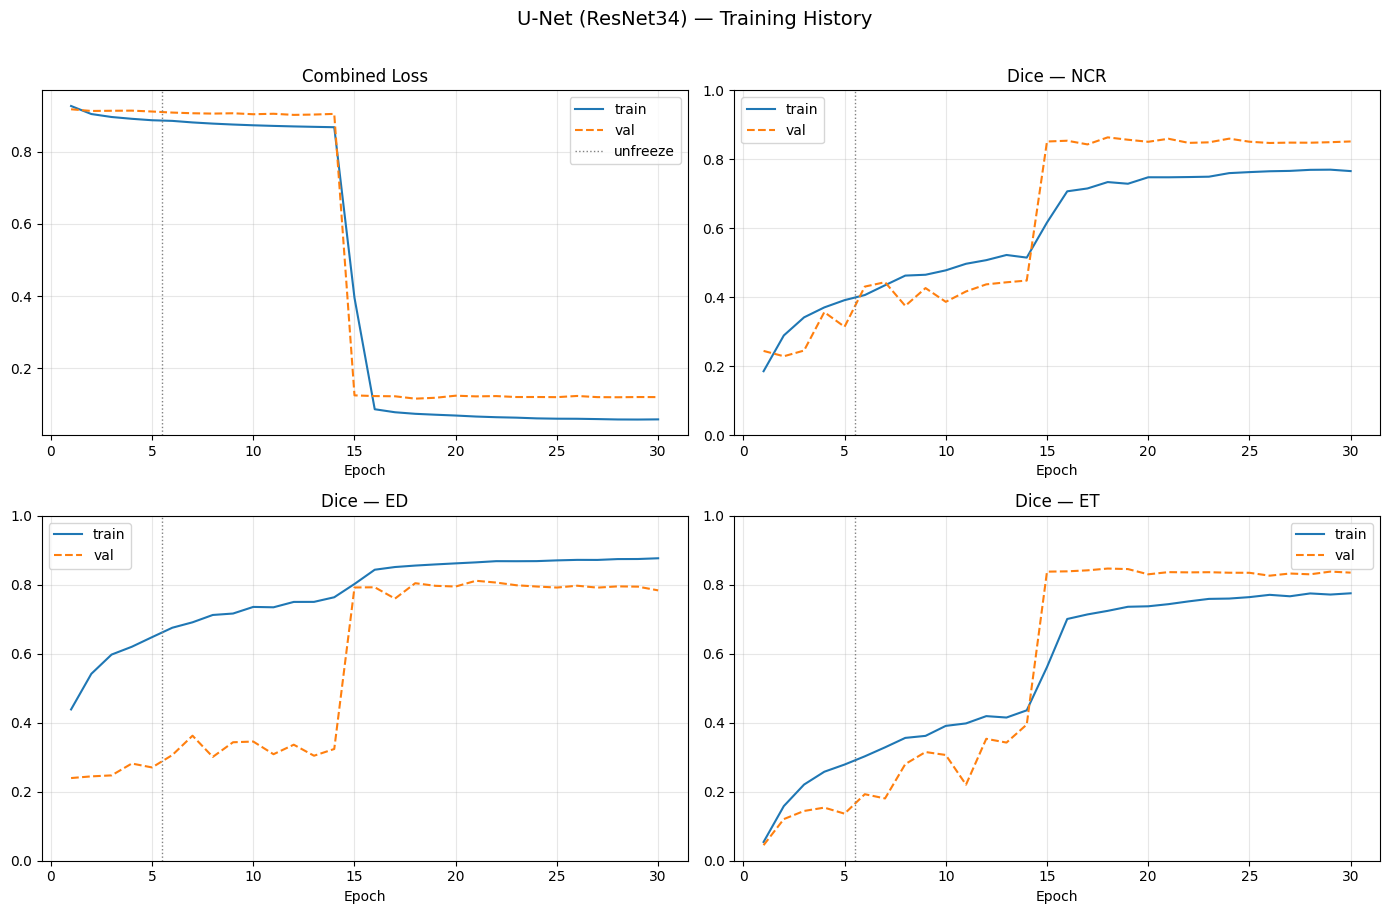

Saved → EDA_02_outputs/unet_training_curves.png


In [11]:
epochs = list(range(1, TOTAL_EPOCHS + 1))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("U-Net (ResNet34) — Training History", fontsize=14, y=1.01)

# ── Loss ────────────────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(epochs, [m["loss"] for m in history["train"]], label="train")
ax.plot(epochs, [m["loss"] for m in history["val"]],   label="val",   linestyle="--")
ax.axvline(PHASE1_EPOCHS + 0.5, color="gray", linestyle=":", linewidth=1, label="unfreeze")
ax.set_title("Combined Loss")
ax.set_xlabel("Epoch")
ax.legend()
ax.grid(True, alpha=0.3)

# ── Dice per class ───────────────────────────────────────────────────────────
class_plot = [("dice_NCR", "NCR"), ("dice_ED", "ED"), ("dice_ET", "ET")]
for i, (key, label) in enumerate(class_plot):
    ax = axes[(i + 1) // 2, (i + 1) % 2]
    ax.plot(epochs, [m[key] for m in history["train"]], label="train")
    ax.plot(epochs, [m[key] for m in history["val"]],   label="val",   linestyle="--")
    ax.axvline(PHASE1_EPOCHS + 0.5, color="gray", linestyle=":", linewidth=1)
    ax.set_title(f"Dice — {label}")
    ax.set_xlabel("Epoch")
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out_dir = PROJECT_ROOT / "training_outputs"
out_dir.mkdir(exist_ok=True)
fig.savefig(str(out_dir / "unet_training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → training_outputs/unet_training_curves.png")

## 9 — Final evaluation on the test set

In [12]:
# Reload best weights for test evaluation
ckpt = load_checkpoint(BEST_CKPT, model, device=DEVICE)
print(f"Loaded best checkpoint from epoch {ckpt['epoch']}")

test_metrics = evaluate(
    model, test_loader, criterion, DEVICE, crop_size=CROP_SIZE,
)

print("\n" + "=" * 50)
print("TEST SET RESULTS")
print("=" * 50)
for k, v in sorted(test_metrics.items()):
    print(f"  {k:<20s}: {v:.4f}")

fg_test = np.mean([test_metrics["dice_NCR"], test_metrics["dice_ED"], test_metrics["dice_ET"]])
print(f"\n  {'mean_fg_dice':<20s}: {fg_test:.4f}")

Loaded best checkpoint from epoch 18



TEST SET RESULTS
  dice_ED             : 0.8111
  dice_ET             : 0.8202
  dice_NCR            : 0.8060
  dice_background     : 0.9987
  dice_loss           : 0.1249
  focal_loss          : 0.0217
  loss                : 0.1466

  mean_fg_dice        : 0.8124


## 10 — Qualitative predictions on validation samples

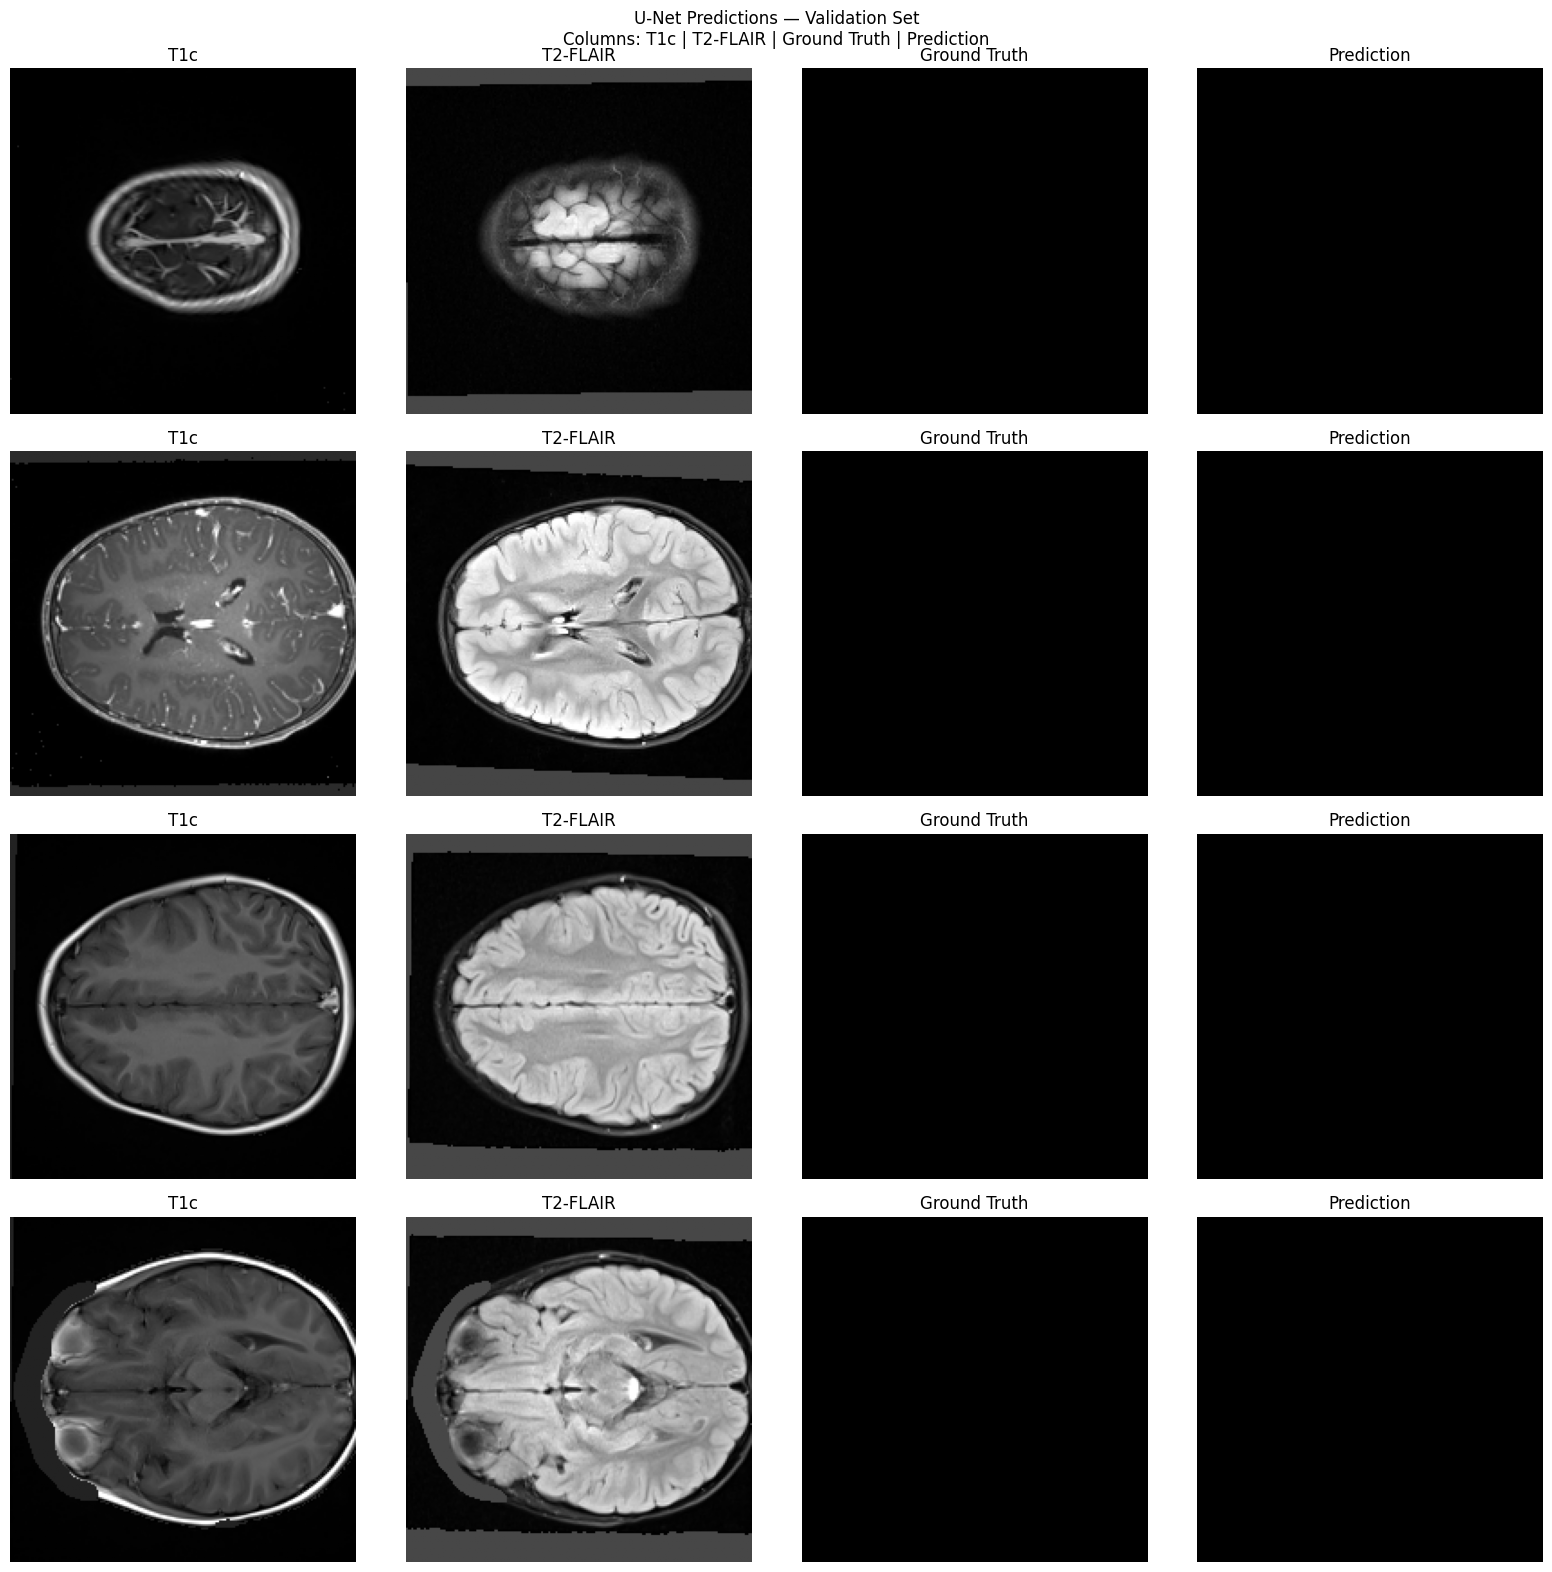

Saved → EDA_02_outputs/unet_val_predictions.png


In [13]:
LABEL_COLORS = {
    0: [0,   0,   0  ],   # Background — black
    1: [255, 50,  50 ],   # NCR        — red
    2: [50,  200, 50 ],   # ED         — green
    3: [50,  100, 255],   # ET         — blue
}

def mask_to_rgb(mask_2d: np.ndarray) -> np.ndarray:
    """Convert integer mask [H,W] → RGB [H,W,3] for visualisation."""
    rgb = np.zeros((*mask_2d.shape, 3), dtype=np.uint8)
    for label, color in LABEL_COLORS.items():
        rgb[mask_2d == label] = color
    return rgb


from src.train_utils import center_crop

model.eval()
N_SHOW = 4

# Sample N_SHOW batches from val loader (batch_size=1 for clarity)
single_loader = DataLoader(val_ds, batch_size=1, shuffle=True)

fig, axes = plt.subplots(N_SHOW, 4, figsize=(16, N_SHOW * 4))
fig.suptitle("U-Net Predictions — Validation Set\n"
             "Columns: T1c | T2-FLAIR | Ground Truth | Prediction",
             fontsize=12)

with torch.no_grad():
    for row, (img, mask) in enumerate(single_loader):
        if row >= N_SHOW:
            break

        img_dev  = img.to(DEVICE)
        img_crop, mask_crop = center_crop(img_dev, mask.to(DEVICE), CROP_SIZE)

        logits = model(img_crop)              # [1, C, 192, 192]
        pred   = logits.argmax(dim=1)[0].cpu().numpy()   # [192, 192]
        gt     = mask_crop[0].cpu().numpy()              # [192, 192]
        t1c    = img_crop[0, 0].cpu().numpy()            # [192, 192]
        t2f    = img_crop[0, 2].cpu().numpy()            # [192, 192]

        axes[row, 0].imshow(t1c, cmap="gray")
        axes[row, 0].set_title("T1c")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(t2f, cmap="gray")
        axes[row, 1].set_title("T2-FLAIR")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(mask_to_rgb(gt))
        axes[row, 2].set_title("Ground Truth")
        axes[row, 2].axis("off")

        axes[row, 3].imshow(mask_to_rgb(pred))
        axes[row, 3].set_title("Prediction")
        axes[row, 3].axis("off")

plt.tight_layout()
fig.savefig(str(out_dir / "unet_val_predictions.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved → training_outputs/unet_val_predictions.png")


## 11 — Save training history (JSON)

In [14]:
history_path = str(CKPT_DIR / "history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)
print(f"Training history saved → {history_path}")

Training history saved → C:\Users\lrnzp\OneDrive\Desktop\POLITO\MAGISTRALE\Secondo Anno\Primo Semestre\AI in Medicine\Project\checkpoints\unet\history.json
